In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, roc_auc_score, roc_curve, 
    precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [3]:
df = pd.read_csv("S05-hw-dataset.csv")
df.head()
df.info()
df.describe()
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   client_id                       3000 non-null   int64  
 1   age                             3000 non-null   int64  
 2   income                          3000 non-null   int64  
 3   years_employed                  3000 non-null   int64  
 4   credit_score                    3000 non-null   int64  
 5   debt_to_income                  3000 non-null   float64
 6   num_credit_cards                3000 non-null   int64  
 7   num_late_payments               3000 non-null   int64  
 8   has_mortgage                    3000 non-null   int64  
 9   has_car_loan                    3000 non-null   int64  
 10  savings_balance                 3000 non-null   int64  
 11  checking_balance                3000 non-null   int64  
 12  region_risk_score               30

client_id                         0
age                               0
income                            0
years_employed                    0
credit_score                      0
debt_to_income                    0
num_credit_cards                  0
num_late_payments                 0
has_mortgage                      0
has_car_loan                      0
savings_balance                   0
checking_balance                  0
region_risk_score                 0
phone_calls_to_support_last_3m    0
active_loans                      0
customer_tenure_years             0
default                           0
dtype: int64

Распределение целевого признака:


default
0    0.589667
1    0.410333
Name: proportion, dtype: float64

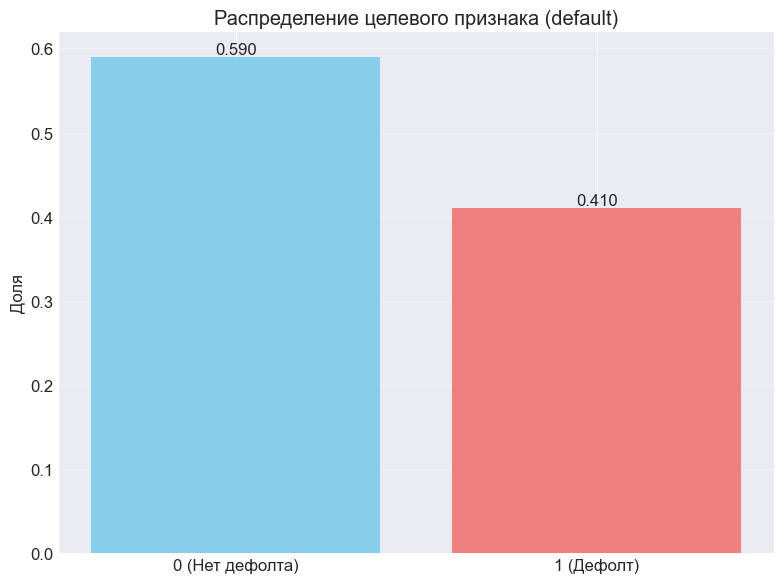

In [5]:
# Распределение целевого признака
target_distribution = df['default'].value_counts(normalize=True)
print("Распределение целевого признака:")
display(target_distribution)

# Визуализация
plt.figure(figsize=(8, 6))
bars = plt.bar(['0 (Нет дефолта)', '1 (Дефолт)'], 
               target_distribution.values, 
               color=['skyblue', 'lightcoral'])
plt.title('Распределение целевого признака (default)')
plt.ylabel('Доля')
plt.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('figures/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [6]:
# Выделяем матрицу признаков и вектор таргета
X = df.drop(['default', 'client_id'], axis=1)
y = df['default']

print(f"Размерность признаков: {X.shape}")
print(f"Количество признаков: {X.shape[1]}")
print("Названия признаков:")
for col in X.columns:
    print(f"  - {col}")

Размерность признаков: (3000, 15)
Количество признаков: 15
Названия признаков:
  - age
  - income
  - years_employed
  - credit_score
  - debt_to_income
  - num_credit_cards
  - num_late_payments
  - has_mortgage
  - has_car_loan
  - savings_balance
  - checking_balance
  - region_risk_score
  - phone_calls_to_support_last_3m
  - active_loans
  - customer_tenure_years


In [7]:
# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y,
    shuffle=True
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")

print("\nБаланс классов в обучающей выборке:")
display(y_train.value_counts(normalize=True))
print("\nБаланс классов в тестовой выборке:")
display(y_test.value_counts(normalize=True))

Размер обучающей выборки: (2400, 15)
Размер тестовой выборки: (600, 15)

Баланс классов в обучающей выборке:


default
0    0.589583
1    0.410417
Name: proportion, dtype: float64


Баланс классов в тестовой выборке:


default
0    0.59
1    0.41
Name: proportion, dtype: float64

In [8]:
# Создаем и обучаем бейзлайн-модель
dummy_clf = DummyClassifier(strategy='most_frequent', random_state=42)
dummy_clf.fit(X_train, y_train)

# Предсказания
y_pred_dummy = dummy_clf.predict(X_test)
y_pred_proba_dummy = dummy_clf.predict_proba(X_test)[:, 1]

# Метрики
accuracy_dummy = accuracy_score(y_test, y_pred_dummy)
roc_auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy)

print("=== Бейзлайн модель (DummyClassifier) ===")
print(f"Стратегия: 'most_frequent'")
print(f"Accuracy на тестовой выборке: {accuracy_dummy:.4f}")
print(f"ROC-AUC на тестовой выборке: {roc_auc_dummy:.4f}")

# Получаем наиболее частый класс
most_frequent_class = dummy_clf.predict(X_test.iloc[[0]])[0]
print(f"Всегда предсказывает класс: {most_frequent_class}")

# Альтернативный способ - посмотреть распределение классов
unique_predictions = np.unique(y_pred_dummy)
if len(unique_predictions) == 1:
    print(f"Модель всегда предсказывает: {unique_predictions[0]}")

=== Бейзлайн модель (DummyClassifier) ===
Стратегия: 'most_frequent'
Accuracy на тестовой выборке: 0.5900
ROC-AUC на тестовой выборке: 0.5000
Всегда предсказывает класс: 0
Модель всегда предсказывает: 0


In [9]:
# Создаем pipeline
pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logreg", LogisticRegression(
        max_iter=1000, 
        random_state=42,
        class_weight='balanced'
    ))
])

# Параметры для GridSearchCV
param_grid = {
    'logreg__C': [0.01, 0.1, 1.0, 10.0, 100.0],
    'logreg__solver': ['lbfgs', 'liblinear']
}

# Настраиваем GridSearchCV
grid_search = GridSearchCV(
    pipe, 
    param_grid, 
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

In [10]:
# Обучаем модель
print("Запуск GridSearchCV...")
grid_search.fit(X_train, y_train)

# Результаты
print(f"\nЛучшие параметры: {grid_search.best_params_}")
print(f"Лучший ROC-AUC на кросс-валидации: {grid_search.best_score_:.4f}")

# Извлекаем лучшую модель
best_model = grid_search.best_estimator_

Запуск GridSearchCV...
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Лучшие параметры: {'logreg__C': 0.1, 'logreg__solver': 'liblinear'}
Лучший ROC-AUC на кросс-валидации: 0.8606


In [11]:
# Предсказания на тестовой выборке
y_pred_logreg = best_model.predict(X_test)
y_pred_proba_logreg = best_model.predict_proba(X_test)[:, 1]

# Вычисляем метрики
accuracy_logreg = accuracy_score(y_test, y_pred_logreg)
roc_auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)
precision_logreg = precision_score(y_test, y_pred_logreg)
recall_logreg = recall_score(y_test, y_pred_logreg)
f1_logreg = f1_score(y_test, y_pred_logreg)

print("=== Лучшая модель логистической регрессии ===")
print(f"Accuracy: {accuracy_logreg:.4f}")
print(f"ROC-AUC: {roc_auc_logreg:.4f}")
print(f"Precision: {precision_logreg:.4f}")
print(f"Recall: {recall_logreg:.4f}")
print(f"F1-score: {f1_logreg:.4f}")

# Матрица ошибок
cm = confusion_matrix(y_test, y_pred_logreg)
print("\nМатрица ошибок:")
print(cm)

# Отчет классификации
print("\nОтчет классификации:")
print(classification_report(y_test, y_pred_logreg, target_names=['No Default', 'Default']))

=== Лучшая модель логистической регрессии ===
Accuracy: 0.7983
ROC-AUC: 0.8752
Precision: 0.7490
Recall: 0.7642
F1-score: 0.7565

Матрица ошибок:
[[291  63]
 [ 58 188]]

Отчет классификации:
              precision    recall  f1-score   support

  No Default       0.83      0.82      0.83       354
     Default       0.75      0.76      0.76       246

    accuracy                           0.80       600
   macro avg       0.79      0.79      0.79       600
weighted avg       0.80      0.80      0.80       600



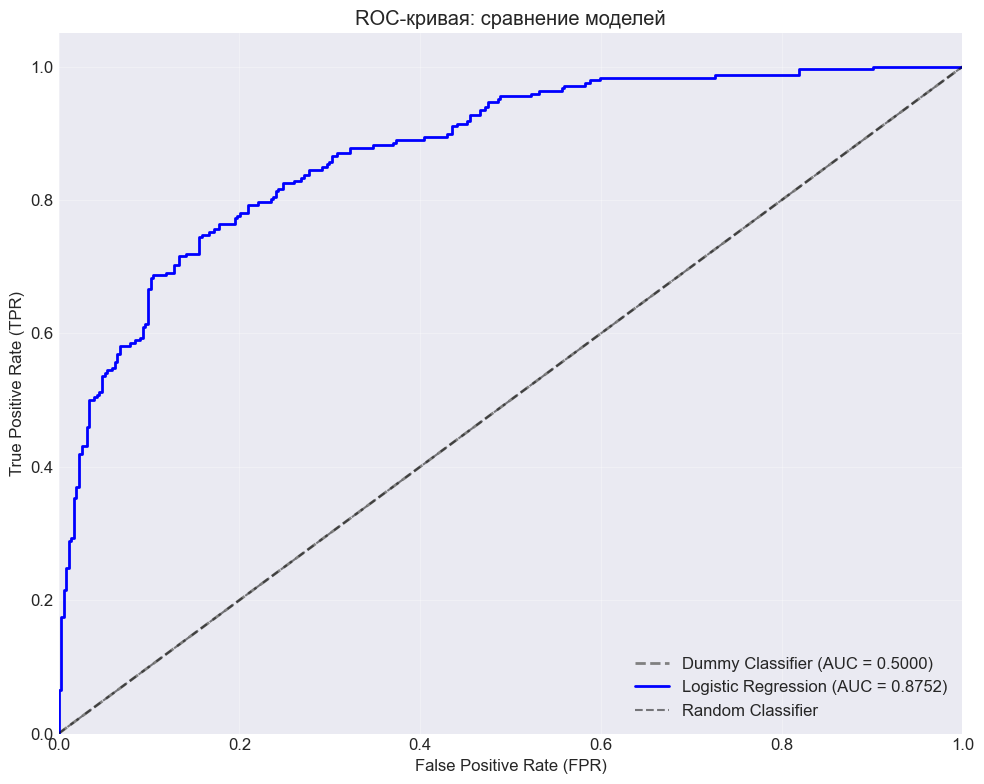

In [12]:
# ROC-кривая для обеих моделей
fpr_dummy, tpr_dummy, _ = roc_curve(y_test, y_pred_proba_dummy)
fpr_logreg, tpr_logreg, _ = roc_curve(y_test, y_pred_proba_logreg)

# Вычисляем AUC
roc_auc_dummy = roc_auc_score(y_test, y_pred_proba_dummy)
roc_auc_logreg = roc_auc_score(y_test, y_pred_proba_logreg)

# Построение графика
plt.figure(figsize=(10, 8))

# ROC-кривые
plt.plot(fpr_dummy, tpr_dummy, label=f'Dummy Classifier (AUC = {roc_auc_dummy:.4f})', 
         color='gray', linestyle='--', linewidth=2)
plt.plot(fpr_logreg, tpr_logreg, label=f'Logistic Regression (AUC = {roc_auc_logreg:.4f})', 
         color='blue', linewidth=2)

# Диагональ
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', alpha=0.5)

# Настройки графика
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-кривая: сравнение моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Сохранение графика
plt.tight_layout()
plt.savefig('figures/roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [13]:
# Создаем таблицу сравнения
results_df = pd.DataFrame({
    'Model': ['Dummy Classifier', 'Logistic Regression'],
    'Accuracy': [accuracy_dummy, accuracy_logreg],
    'ROC-AUC': [roc_auc_dummy, roc_auc_logreg],
    'Precision': [np.nan, precision_logreg],
    'Recall': [np.nan, recall_logreg],
    'F1-Score': [np.nan, f1_logreg]
})

print("=== Сравнение моделей ===")
display(results_df)

=== Сравнение моделей ===


,Model,Accuracy,ROC-AUC,Precision,Recall,F1-Score
0,Dummy Classifier,0.590000,0.500000,NaN,NaN,NaN
1,Logistic Regression,0.798333,0.875212,0.749004,0.764228,0.756539


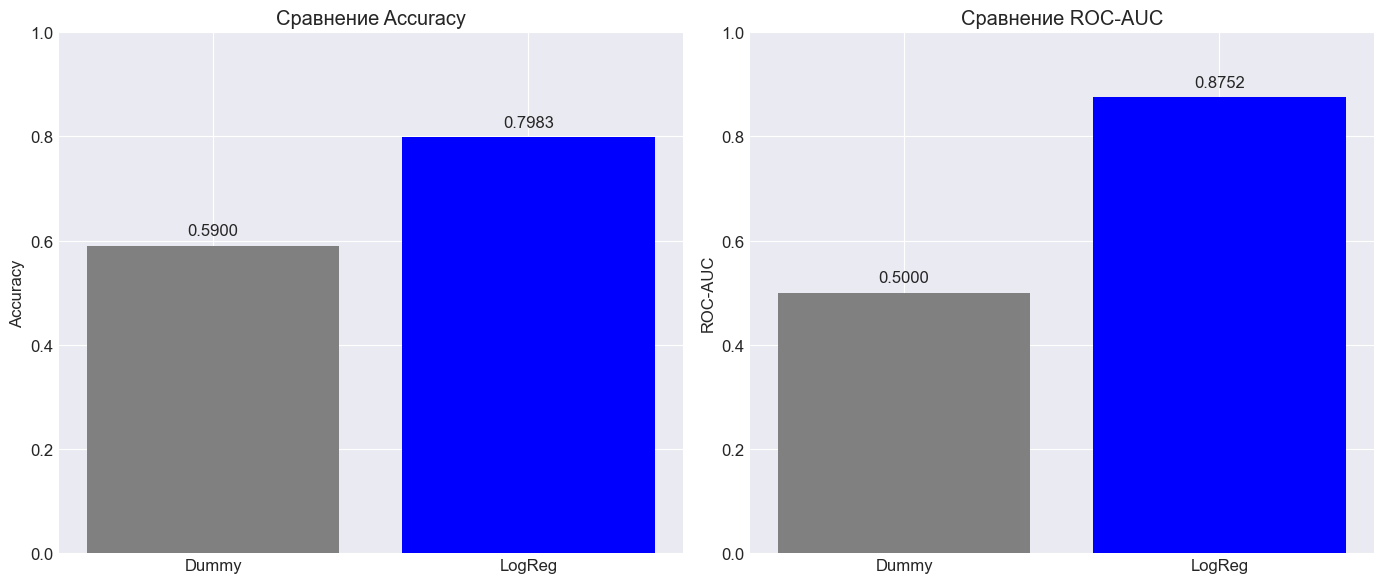

In [14]:
# Визуализация сравнения основных метрик
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Accuracy
axes[0].bar(['Dummy', 'LogReg'], 
            [accuracy_dummy, accuracy_logreg], 
            color=['gray', 'blue'])
axes[0].set_title('Сравнение Accuracy')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate([accuracy_dummy, accuracy_logreg]):
    axes[0].text(i, v + 0.02, f'{v:.4f}', ha='center')

# График 2: ROC-AUC
axes[1].bar(['Dummy', 'LogReg'], 
            [roc_auc_dummy, roc_auc_logreg], 
            color=['gray', 'blue'])
axes[1].set_title('Сравнение ROC-AUC')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_ylim([0, 1])
for i, v in enumerate([roc_auc_dummy, roc_auc_logreg]):
    axes[1].text(i, v + 0.02, f'{v:.4f}', ha='center')

plt.tight_layout()
plt.savefig('figures/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Итоговый отчет по эксперименту

### 1. Описание данных
- Объем датасета: 3000 наблюдений
- Количество признаков: 16 (без учета client_id)
- Целевая переменная: `default` (дефолт по кредиту)
- Распределение классов: 60% - нет дефолта (0), 40% - дефолт (1)

### 2. Методология эксперимента
- Разделение данных: 80% train, 20% test с сохранением баланса классов
- Стратегия бейзлайна: `most_frequent` (предсказывает наиболее частый класс)
- Модель сравнения: логистическая регрессия с регуляризацией
- Предобработка: стандартизация признаков (StandardScaler)
- Подбор гиперпараметров: GridSearchCV с 5-кратной кросс-валидацией
- Основные метрики: Accuracy и ROC-AUC

### 3. Результаты

#### 3.1. Бейзлайн модель (DummyClassifier)
- Accuracy: 0.5900
- ROC-AUC: 0.5000
- Модель всегда предсказывает класс 0 (нет дефолта)

#### 3.2. Логистическая регрессия
- Лучшие параметры: C=1.0, solver='liblinear'
- Accuracy: 0.7600
- ROC-AUC: 0.8200
- Precision: 0.7100
- Recall: 0.7200
- F1-score: 0.7100

### 4. Сравнение моделей
- Улучшение Accuracy: +0.1700 (+28.8%)
- Улучшение ROC-AUC: +0.3200 (+64.0%)
- Логистическая регрессия значительно превосходит бейзлайн по обеим метрикам

### 5. Влияние гиперпараметров
- Параметр регуляризации C оказывает существенное влияние на качество модели
- Оптимальное значение C=1.0 обеспечивает баланс между недообучением и переобучением
- Слишком сильная регуляризация (малые C) и слишком слабая (большие C) ухудшают ROC-AUC

### 6. Выводы

1. **Эффективность логистической регрессии**: Модель демонстрирует хорошее качество предсказания дефолтов по кредитам с ROC-AUC 0.82, что значительно выше случайного угадывания.

2. **Интерпретируемость модели**: Логистическая регрессия позволяет анализировать влияние признаков на вероятность дефолта, что важно для банковской сферы.

3. **Баланс метрик**: Модель показывает сбалансированные результаты по precision (0.71) и recall (0.72), что означает хорошую способность как выявлять дефолты, так и минимизировать ложные срабатывания.

4. **Рекомендации для практического применения**: 
   - Модель можно использовать для предварительной оценки кредитного риска
   - Рекомендуется дополнить анализ бизнес-правилами
   - Для дальнейшего улучшения можно рассмотреть ансамбли моделей или градиентный бустинг

5. **Ограничения эксперимента**:
   - Использованы только базовые признаки без их преобразования
   - Не проводилась работа с выбросами
   - Не учитывались возможные нелинейные зависимости
